<a href="https://colab.research.google.com/github/FlaviaLopes/dio-challenges-coding-the-future-with-baires-dev/blob/main/Redu%C3%A7%C3%A3o_de_Dimensionalidade_em_Imagens_para_Redes_Neurais.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

__Projeto para redução de dimensionalidade em imagens.__

Enunciado:
> "Seguindo o exemplo do algoritmo de binarização apresentado em nossa última aula, realize a implementação em Python para transformar uma imagem colorida para níveis de cinza (0 a 255) e para binarizada (0 e 255), preto e branco. Por meio da imagem é possível visualizar os dois casos esperados:"


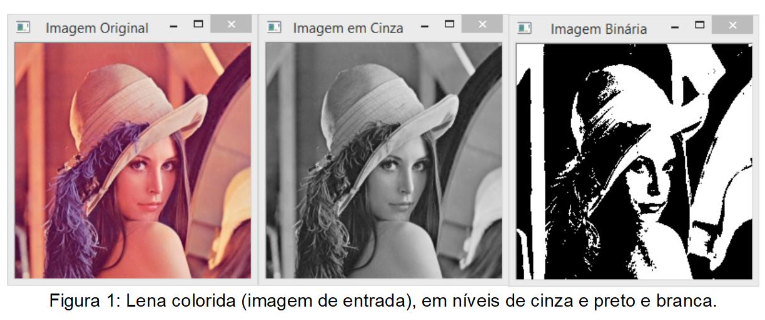

$Mas$, $antes$ $disso$...

__Como é uma imagem em RGB__

O RGB é um modelo de codificação de cores amplamente utilizado para representar e reproduzir cores em dispositivos digitais. É composto por três canais de cores: vermelho, verde e azul. Cada pixel de uma imagem RGB precisa ter três valores, cada um representando a intensidade de luminosidade no seu respectivo canal, e que varia entre 0 e 255. Quando 0, temos ausência de luminosidade, ou a cor preta, quando 255, temos a luminosidade máxima, ou a cor branca. É após a sobreposição dos canais que podemos visualizar a imagem colorida.

Já a escala de cinza é formada pela mistura das cores preta e branca em difentes proporções, e cada tom é um valor entre 0 e 255.

Assim, uma imagem RGB pode ser vista como a união de três imagens em escala de cinza, cada uma representando a intensidade de um canal de cor específico.

__Representação matricial__

Dada uma imagem RGB, esta pode ser representada por uma matriz de dimensão $m$ x $n$ x $z$, onde $m$ é a altura da imagem em pixels, $n$ a largura em pixels, e $z$ é a profundidade da matriz. Cada matriz da dimensão $z$ representa os valores dos canais para a imagem, respectivamente Red, Green e Blue.

- Logo, a matriz que representa a imagem RGB da Lena, possui a seguinte dimensão: 255x255x3.

__Redução de dimensionalidade__

Em casos em que a cor não é uma feature importante, converter a imagem para escala de cinza simplifica bastante o processamento da rede, pois a imagem passa a ter apenas um canal.
Em alguns casos, a variação de luminosidade também não é relevante, e podemos simplificar ainda mais a imagem convertendo-a para preto e branco. Supondo que este seja o caso, a seguir são listadas as transformação necessárias.

- luma transformation: consiste na multiplicação, seguida de soma, de cada canal por uma constante, resultando em uma única matriz.
- Floyd-Steinberg dither: os valores maiores que 127 são transformados em 255,  branco, e os demais 0, preto.


__Agora, as transformações são aplicadas__, conforme solicitado no enunciado, sem usar implementações específicas de bibliotecas especialistas em processamento de imagem.
- PIL: para leitura e exportação das imagens
- Numpy: para manipulação matricial

__Load the data__
- carrega a imagem usando a biblioteca PIL, e garante que esteja em RGB.

In [1]:
from PIL import Image
import numpy as np

image = Image.open('lena.jpeg')
rgb_image = image.convert("RGB")

__Transform the data__
- transforma a imagem em uma matriz de dimensão 255x255x3 (rgb_array)
- cria a matriz de tons de cinza (gray_array) a partir da transformação de rgb_array
- cria a matriz em preto e branco (bw_array) a partir da transformação de gray_array

(225, 225, 3)


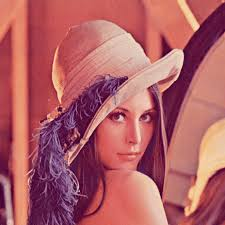

In [2]:
rgb_array = np.array(rgb_image)
print(rgb_array.shape)
rgb_image

(225, 225)


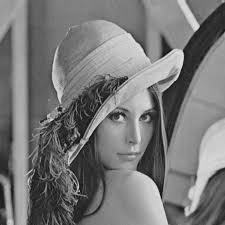

In [3]:
luma_transform = lambda x: x[0:, 0:, 0] * 0.299 + x[0:, 0:, 1] * 0.587 + x[0:, 0:, 2] * 0.114

gray_array = luma_transform(rgb_array).astype(np.uint8)
print(gray_array.shape)

gray_image = Image.fromarray(gray_array, mode='L')
gray_image.save("gray_image.jpg")
gray_image

(225, 225)


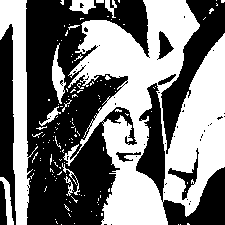

In [4]:
floyd = lambda x: 255 if x > 127 else 0

bw_array = np.vectorize(floyd)(gray_array)
print(bw_array.shape)

bw_image = Image.fromarray(bw_array.astype(np.uint8), mode="L")
bw_image.save("bw_image.jpg")
bw_image

_Este foi o processo básico da redução de dimensionalidade de imagens._

__Até a próxima.__✨🏅